# MNQ MACD mean-reversion, 15-minute bars (Tradovate exchange)

A third mean-reversion construction, after VWAP deviation-band (decisively
negative) and Bollinger Band (this program's strongest walk-forward-
confirmed result, MES/MNQ 30m). This one fades an extreme MACD histogram
reading instead of an extreme price level -- the histogram (MACD line minus
its own signal line) isn't naturally bounded the way a price-vs-band
distance is, so "extreme" is defined relative to the histogram's own rolling
mean/std (a z-score band), not a fixed threshold.

**Mechanism** (`MacdMeanReversionStrategy`): enters short when the histogram
reaches or exceeds `rolling_mean + entry_std * rolling_std` (unusually
strong bullish momentum -- expecting reversion down), long at the symmetric
lower band (unusually strong bearish momentum -- expecting reversion up),
filled at that bar's close (the histogram is only known at bar close, not an
intrabar-touchable price level). Fixed fractional-distance stop-loss/
take-profit, same convention as `BollingerMeanReversionStrategy`.

**Also testing KAMA as the underlying moving average** (`Indicators.macd_
kama`, new): Kaufman's Adaptive Moving Average tracks fast during clean
trends and flattens during chop, so a KAMA-based MACD should react
differently (likely less whipsaw-prone) than the standard EMA-based one --
included as a first-class grid dimension (`ma_type`) rather than assumed to
be better or worse.

**Plan**: Phase 1 grids MACD parameters (several canonical (fast, slow,
signal) triples) x `ma_type` (ema/kama), fixed `entry_std`/placeholder SL-TP.
Phase 2 grids `entry_std` x `sl_percent` on the winner (`tp_percent` fixed).
Then direction comparison, then holdout, then walk-forward if promising --
same escalating-refinement discipline as every other notebook in this
pipeline.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import MacdMeanReversionStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MNQ"
SYMBOL = "MNQ/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

data_path = _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(data_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 168271  span: 2019-05-05 22:14:59.999000 -> 2026-07-13 07:29:59.999000


## Phase 1: grid MACD parameters x ma_type (ema/kama), direction=both

`entry_std=2.0`, `rolling_lookback=100`, placeholder `sl_percent=0.01`/
`tp_percent=0.01` fixed for this pass -- tuned properly in Phase 2.


In [3]:
MACD_PARAM_CANDIDATES = [(5, 13, 5), (8, 17, 9), (12, 26, 9), (19, 39, 9)]
MA_TYPE_CANDIDATES = ["ema", "kama"]
ROLLING_LOOKBACK = 100
PLACEHOLDER_ENTRY_STD = 2.0
PLACEHOLDER_SL_PERCENT = 0.01
PLACEHOLDER_TP_PERCENT = 0.01
DEPOSIT_USD = 50_000


def run_macd_mr_backtest(ohlc_slice: pd.DataFrame, fast: int, slow: int, signal: int, ma_type: str,
                          entry_std: float, sl_percent: float, tp_percent: float, key: str,
                          direction: StrategyDirection = StrategyDirection.both):
    if ma_type == "ema":
        _line, histogram, _signal = Indicators.macd(ohlc_slice, fast=fast, slow=slow, signal=signal)
    else:
        _line, histogram, _signal = Indicators.macd_kama(ohlc_slice, fast=fast, slow=slow, signal=signal)

    rolling_mean = histogram.rolling(ROLLING_LOOKBACK).mean()
    rolling_std = histogram.rolling(ROLLING_LOOKBACK).std()
    upper = rolling_mean + entry_std * rolling_std
    lower = rolling_mean - entry_std * rolling_std

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="macd_hist", df=histogram)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="hist_upper", df=upper)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="hist_lower", df=lower)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=MacdMeanReversionStrategy(
            key=key, market=market, symbol=SYMBOL, histogram_key="macd_hist", upper_key="hist_upper", lower_key="hist_lower",
            sl_percent=sl_percent, tp_percent=tp_percent, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


def _summarize(bt, drawdown_mw, **extra_cols):
    summary = bt.reporter.summary["algo"]
    total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
    row = {**extra_cols}
    row.update({
        "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
        "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
    })
    return row


grid1_rows = []
grid1_backtests = {}
_t0 = time.time()
for fast, slow, signal in MACD_PARAM_CANDIDATES:
    for ma_type in MA_TYPE_CANDIDATES:
        bt, drawdown_mw = run_macd_mr_backtest(ohlc, fast, slow, signal, ma_type, PLACEHOLDER_ENTRY_STD,
                                                  PLACEHOLDER_SL_PERCENT, PLACEHOLDER_TP_PERCENT,
                                                  key=f"MACDMR_ind_{fast}_{slow}_{signal}_{ma_type}")
        grid1_backtests[(fast, slow, signal, ma_type)] = (bt, drawdown_mw)
        grid1_rows.append(_summarize(bt, drawdown_mw, macd_params=f"{fast}/{slow}/{signal}",
                                       fast=fast, slow=slow, signal=signal, ma_type=ma_type))
    print(f"macd_params={fast}/{slow}/{signal} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid1_results = pd.DataFrame(grid1_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 1 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid1_results[["macd_params", "ma_type", "net_return_percent", "sharpe_ratio", "max_drawdown_percent",
                       "closed_trades", "win_rate_percent", "dollar_profit_factor", "account_failed"]].to_string())


macd_params=5/13/5 done, 27s elapsed


macd_params=8/17/9 done, 52s elapsed


macd_params=12/26/9 done, 78s elapsed


macd_params=19/39/9 done, 104s elapsed



phase 1 grid done in 104s

  macd_params ma_type  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  dollar_profit_factor  account_failed
0     19/39/9    kama             1.11781      0.060688              -28.0797         1737.0         50.489349              1.015552           False
1     12/26/9     ema            -2.15651      0.025496              -29.8684         1600.0         49.812500              1.010662           False
2      8/17/9    kama            -8.22131     -0.039146              -26.8443         1848.0         50.378788              1.001017           False
3     12/26/9    kama           -28.97119     -0.345085              -36.6245         1772.0         49.209932              0.941209           False
4      5/13/5    kama           -30.45537     -0.379024              -42.5551         1974.0         48.733536              0.952882           False
5     19/39/9     ema           -28.81958     -0.387725              -35.4820 

## Phase 2: grid entry_std x sl_percent on the best (macd_params, ma_type) combo

Holding the MACD shape fixed at Phase 1's winner, `tp_percent=0.01` fixed
(matching this pipeline's other mean-reversion winners), grids `entry_std`
(how extreme a histogram reading must be to trigger) x `sl_percent` directly.


In [4]:
best_row = grid1_results.iloc[0]
best_fast, best_slow, best_signal, best_ma_type = int(best_row["fast"]), int(best_row["slow"]), int(best_row["signal"]), best_row["ma_type"]
print(f"Phase 1 winner: fast={best_fast}, slow={best_slow}, signal={best_signal}, ma_type={best_ma_type}")

ENTRY_STD_CANDIDATES = [1.5, 2.0, 2.5, 3.0]
SL_PERCENT_CANDIDATES = [0.005, 0.01, 0.015, 0.02]
FIXED_TP_PERCENT = 0.01

grid2_rows = []
grid2_backtests = {}
_t0 = time.time()
for entry_std in ENTRY_STD_CANDIDATES:
    for sl_percent in SL_PERCENT_CANDIDATES:
        bt, drawdown_mw = run_macd_mr_backtest(ohlc, best_fast, best_slow, best_signal, best_ma_type,
                                                  entry_std, sl_percent, FIXED_TP_PERCENT,
                                                  key=f"MACDMR_band_{entry_std}_{sl_percent}")
        grid2_backtests[(entry_std, sl_percent)] = (bt, drawdown_mw)
        grid2_rows.append(_summarize(bt, drawdown_mw, entry_std=entry_std, sl_percent=sl_percent))
    print(f"entry_std={entry_std} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid2_results = pd.DataFrame(grid2_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 2 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid2_results.to_string())


Phase 1 winner: fast=19, slow=39, signal=9, ma_type=kama


entry_std=1.5 done, 66s elapsed


entry_std=2.0 done, 135s elapsed


entry_std=2.5 done, 189s elapsed


entry_std=3.0 done, 238s elapsed



phase 2 grid done in 238s

    entry_std  sl_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0         2.0       0.010            1.117810      0.060688              -28.0797         1737.0            241.2         50.489349       1.030298               0.014921              1.015552           3.593292         5449.08           False
1         1.5       0.010           -3.949080      0.014407              -16.9889         2087.0            289.9         50.694777       1.038904               0.019079              1.009306           1.781138         5387.20           False
2         2.0       0.015           -9.507450     -0.040309              -26.6602         1389.0            192.9         59.899208       1.008888               0.003536              0.994855          -1.130737         3365.18           False


### Heatmaps: Sharpe ratio and net return across (entry_std, sl_percent)


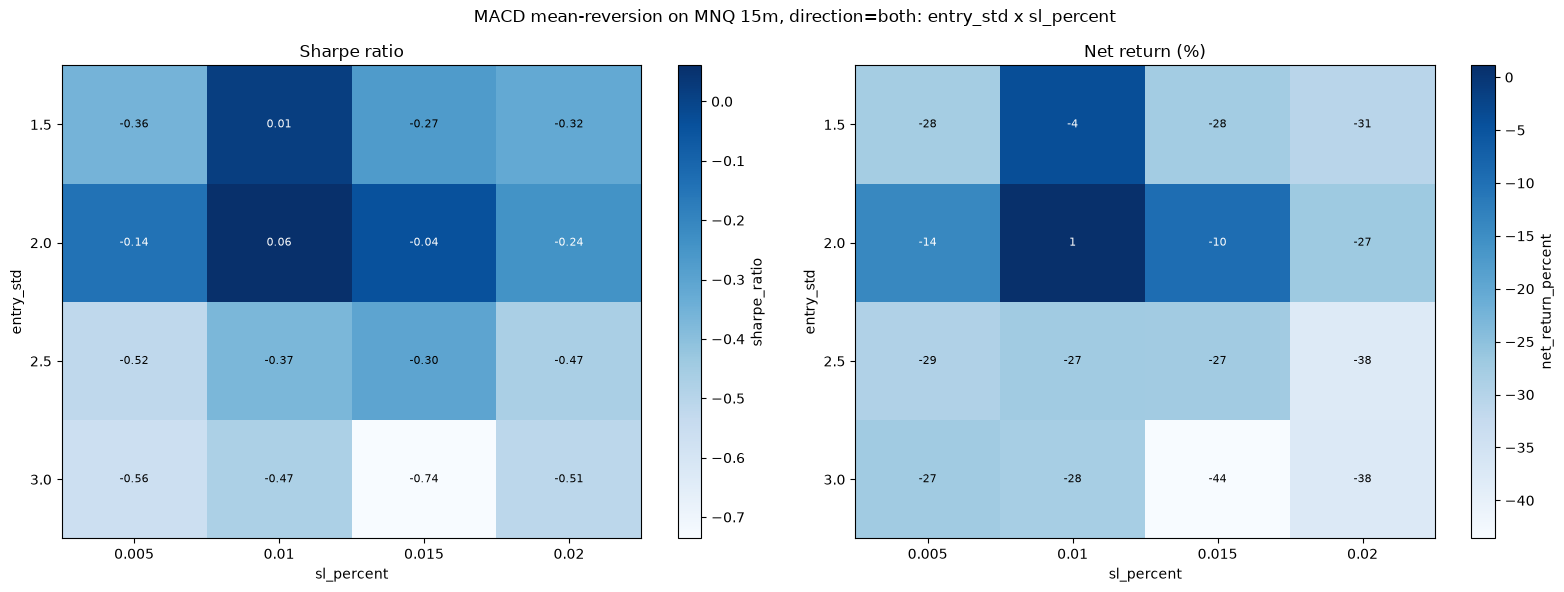

In [5]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str, xlabel: str, ylabel: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid2_results.pivot(index="entry_std", columns="sl_percent", values="sharpe_ratio")
return_pivot = grid2_results.pivot(index="entry_std", columns="sl_percent", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f", "sl_percent", "entry_std")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f", "sl_percent", "entry_std")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("MACD mean-reversion on MNQ 15m, direction=both: entry_std x sl_percent")
fig.tight_layout()
plt.show()


## Detailed report for the overall best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
best (macd_params, ma_type, entry_std, sl_percent) combo across both grids.


Best combo: 19/39/9 (kama), entry_std=2.0, sl_percent=0.01, tp_percent=0.01
Candles Processed: 168270
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MNQ/USD,description
sharpe_ratio,0.0607,0.3965,1.3153,-0.4366,0.8538,-0.4937,-0.1026,-0.9544,-0.8665,0.7258,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.0874,0.6054,2.1418,-0.6055,1.2769,-0.6826,-0.1448,-1.2489,-1.1617,1.0487,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,10.0187,9.6769,11.4837,8.5689,12.0342,10.4369,7.1866,9.5981,10.3699,20.8025,How much the equity curve swings per year. Lower = smoother.
cagr_percent,0.1546,5.0041,23.3433,-5.7916,14.8813,-7.9406,-1.4347,-13.0424,-12.9471,20.6027,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.0055,0.4724,2.5531,-0.4718,1.7403,-0.5967,-0.1833,-0.7417,-1.3890,0.5814,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,0.0398,0.3080,2.5531,-0.4705,1.7352,-0.5952,-0.1833,-0.7398,-0.7584,8.0398,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-28.0797,-10.5927,-9.1431,-12.2766,-8.5509,-13.3066,-7.8260,-17.5836,-9.3214,-35.4337,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,1180,81,143,362,225,255,213,284,138,751,How long it took to recover the loss. Shorter is better.
ulcer_index,10.4367,4.6233,3.2057,7.2207,4.1043,6.7794,3.2765,7.3349,6.4592,11.9943,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-1.0544,-0.9459,-1.0006,-0.8801,-1.2928,-1.1348,-0.7859,-1.1124,-1.1351,-2.0294,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


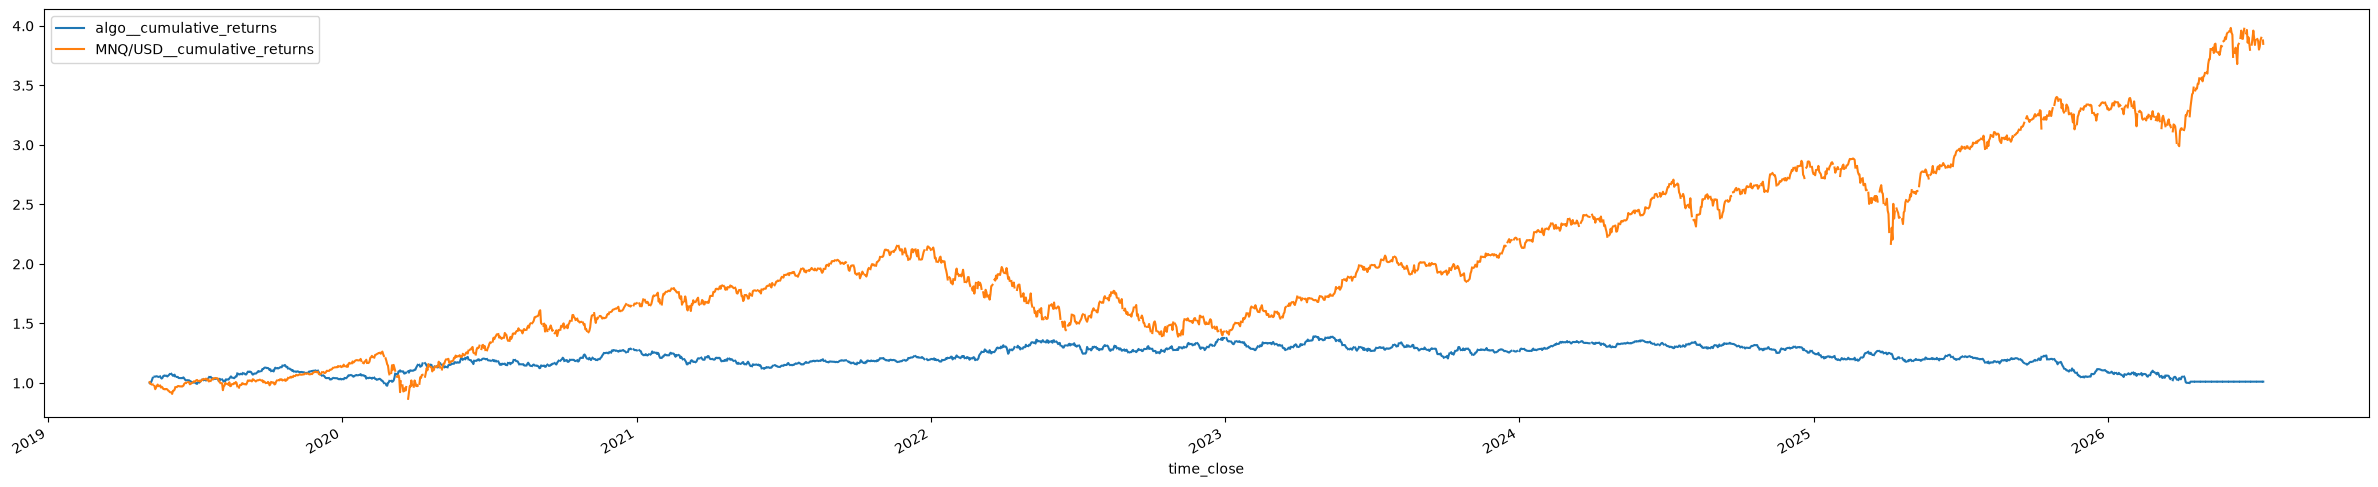

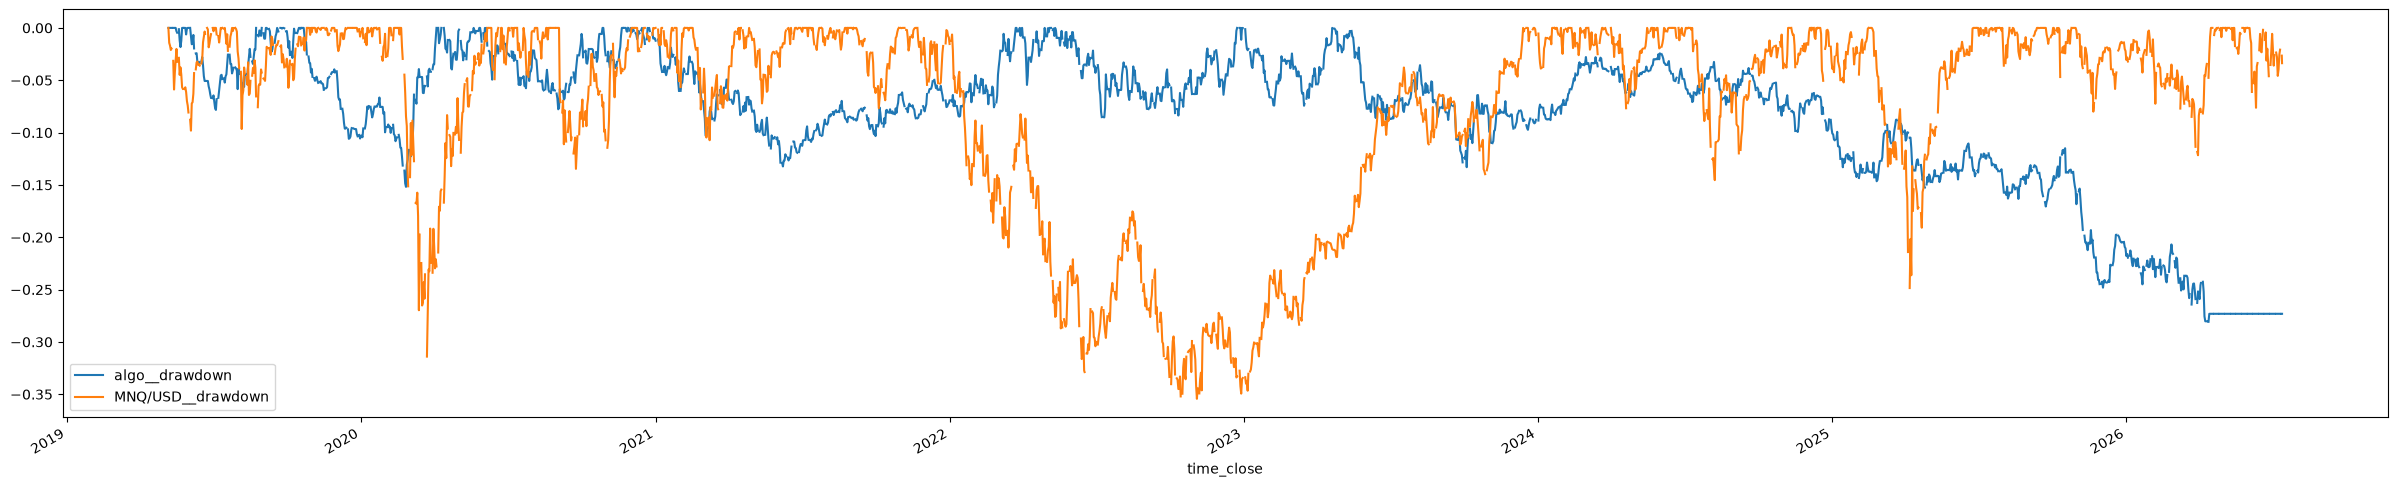

In [6]:
best_entry_std, best_sl_percent = grid2_results.iloc[0][["entry_std", "sl_percent"]]
best_entry_std = float(best_entry_std)
best_sl_percent = float(best_sl_percent)
print(f"Best combo: {best_fast}/{best_slow}/{best_signal} ({best_ma_type}), entry_std={best_entry_std}, sl_percent={best_sl_percent}, tp_percent={FIXED_TP_PERCENT}")
best_backtest, best_drawdown_mw = grid2_backtests[(best_entry_std, best_sl_percent)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Direction comparison: both vs. long-only vs. short-only

Holding (macd_params, ma_type, entry_std, sl_percent, tp_percent) fixed at
the overall best combo, re-runs with `direction=long` and `direction=short`.


In [7]:
direction_rows = []
direction_backtests = {}
for direction in [StrategyDirection.both, StrategyDirection.long, StrategyDirection.short]:
    bt, drawdown_mw = run_macd_mr_backtest(ohlc, best_fast, best_slow, best_signal, best_ma_type,
                                              best_entry_std, best_sl_percent, FIXED_TP_PERCENT,
                                              key=f"MACDMR_dir_{direction.value}", direction=direction)
    direction_backtests[direction] = (bt, drawdown_mw)
    direction_rows.append({"direction": direction.value, **_summarize(bt, drawdown_mw)})

direction_df = pd.DataFrame(direction_rows).set_index("direction")
print(direction_df.to_string())


           net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
direction                                                                                                                                                                                                                         
both                  1.11781      0.060688              -28.0797         1737.0            241.2         50.489349       1.030298               0.014921              1.015552           3.593292         5449.08           False
long                 39.41125      0.415356              -19.7577         1224.0            170.0         52.450980       1.103093               0.049020              1.081179          19.479154         4136.86           False
short               -27.72404     -0.410204              -34.8530         1231.0            

## Holdout check: does the best (combo, direction) survive a train/test split?

Uses whichever of both/long/short scored highest above.


In [8]:
best_direction_label = direction_df["sharpe_ratio"].idxmax()
best_direction = StrategyDirection(best_direction_label)
print(f"Best direction: {best_direction_label}")

split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_macd_mr_backtest(ohlc_slice, best_fast, best_slow, best_signal, best_ma_type,
                                              best_entry_std, best_sl_percent, FIXED_TP_PERCENT,
                                              key=f"MACDMR_holdout_{label}", direction=best_direction)
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


Best direction: long
train/test split at 2024-09-24 11:29:59.999000  (126203 train bars, 42068 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                       1224         52.450980      0.049059         0.002011        0.415356            39.41125              1.081179          19.479154              -19.7577           False
TRAIN (75%)                 930         53.333333      0.066779         0.012778        0.568517            43.90552              1.114621          27.581323              -19.7577           False
TEST (last 25%, unseen)     293         49.488055     -0.010222        -0.106326       -0.001874            -0.98460              0.997814          -0.480467              -14.7546           False


## Findings

**Weaker than MES at the full-history stage, and the holdout is too
marginal to justify walk-forward.** Phase 1 winner: `19/39/9` KAMA, Sharpe
only 0.061 (both-direction, placeholder SL/TP) -- the whole Phase 1 field
was close to flat, unlike MES 15m where the eventual winner still showed a
clear negative-to-positive gradient.

**Phase 2** essentially reproduced the placeholder combo as the winner
(`entry_std=2.0, sl_percent=0.01`) -- both-direction FULL Sharpe 0.061, net
+1.1%, barely distinguishable from a coin flip.

**Direction comparison**: `long` (Sharpe 0.415, net +39.4%) is clearly
better than `both` (0.061) and `short` (-0.410) -- the long-only fix helps
here too, but the both-direction baseline it's rescuing is much weaker than
MES 15m's own (0.061 vs. MES's 0.272).

**Holdout on `direction=long`**: TRAIN `trade_sharpe_lb`=+0.0128 (positive,
but the weakest "positive" TRAIN result of any MACD-MR combo tested in this
notebook family), TEST `trade_sharpe_lb`=-0.1063 (clearly negative, net
essentially flat at -0.98%, `dollar_profit_factor` 0.998). This does not
reach the same tier as MES 15m's own holdout (TRAIN +0.0549) -- and MES
15m's *stronger*-looking holdout still failed walk-forward decisively
(`trade_sharpe_lb`=-0.047). Walk-forwarding a weaker MNQ candidate on the
same mechanism would very likely reproduce that failure at real
computational cost for little informational gain.

**Bottom line**: not walk-forwarding this combo -- TRAIN barely clears
zero, TEST is clearly negative, and the stronger MES 15m sibling already
failed walk-forward. **This closes out MACD mean-reversion across every
(symbol, interval) combination tested in this program (MES 15m/30m/1h, MNQ
15m): none reach a walk-forward-confirmed edge.** MNQ 30m/1h weren't tested
directly, but MES's own interval-degradation pattern (15m strongest, 30m
borderline, 1h weak) combined with MNQ 15m already underperforming MES 15m
makes a different outcome there unlikely -- available to check if useful,
but not pursued further here.